#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [ ]:


import pandas as pd
app_data = pd.read_csv('/content/application_data.csv')
columns_description = pd.read_csv('/content/columns_description.csv')
prev_app = pd.read_csv('/content/previous_application.csv')

In [ ]:
import seaborn as sns

In [ ]:
# Quick look / basic analysis
print("app_data:", app_data.shape)
print("prev_app:", prev_app.shape)
print("columns_description:", columns_description.shape)

app_data.head()

app_data: (307511, 122)
prev_app: (1670214, 37)
columns_description: (160, 5)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Slide 1 Target analysis (How common is default)
# Default counts + default rate
app_data['TARGET'].value_counts()


,count
TARGET,
0,282686
1,24825


In [ ]:
app_data['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


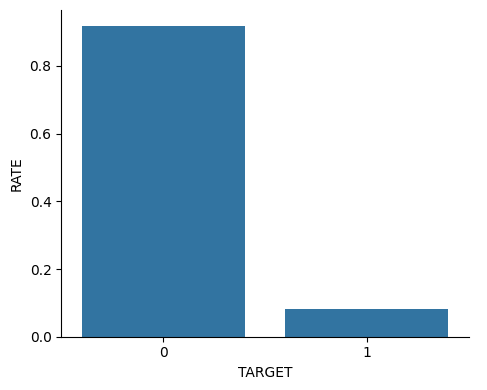

In [ ]:
# Plot: default share
'''Default is when TARGET =1 hence we identify risk driver'''
target_df = app_data['TARGET'].value_counts(normalize=True).reset_index()
target_df.columns = ['TARGET', 'RATE']
sns.catplot(data=target_df, kind="bar", x="TARGET", y="RATE", height=4, aspect=1.2)

In [ ]:
# Slide 2 (Income vs default)

''' defaulters have “Defaulters have loweraverage income than non-defaulters → suggests repayment capacity is a key risk driver.”

app_data.groupby('TARGET')['AMT_INCOME_TOTAL'].mean()


SyntaxError: incomplete input (2990714787.py, line 3)

In [ ]:
app_data.groupby('TARGET')['AMT_INCOME_TOTAL'].median()

,AMT_INCOME_TOTAL
TARGET,
0,148500.0
1,135000.0


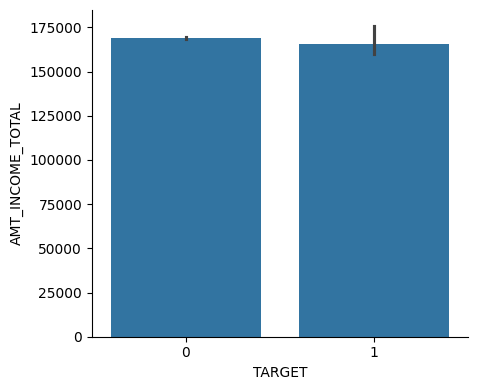

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AMT_INCOME_TOTAL", height=4, aspect=1.2)

In [ ]:
#Slide 2 (credit vs default)

In [ ]:
app_data.groupby('TARGET')['AMT_CREDIT'].mean()


,AMT_CREDIT
TARGET,
0,602648.282002
1,557778.527674


In [ ]:
app_data.groupby('TARGET')['AMT_CREDIT'].median()

,AMT_CREDIT
TARGET,
0,517788.0
1,497520.0


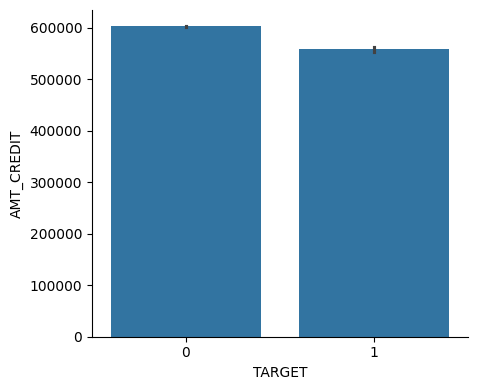

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AMT_CREDIT", height=4, aspect=1.2)

In [ ]:
#Slide 4 (annuity vs default)

''' Defaulters have a lower average annuity than non-defaulters → suggests repayment capacity is a key risk driver.'''

In [ ]:
app_data.groupby('TARGET')['AMT_ANNUITY'].mean()


,AMT_ANNUITY
TARGET,
0,27163.623349
1,26481.744290


In [ ]:
app_data.groupby('TARGET')['AMT_ANNUITY'].median()

,AMT_ANNUITY
TARGET,
0,24876.0
1,25263.0


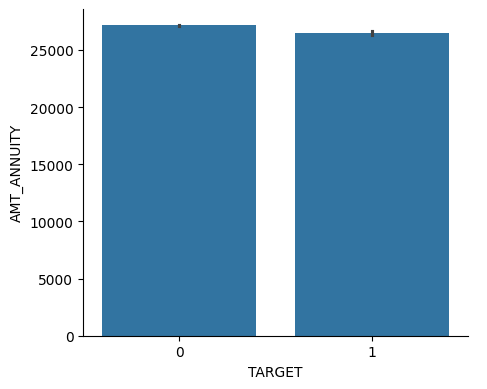

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AMT_ANNUITY", height=4, aspect=1.2)

In [ ]:
#slide 5 - age vs default

''' defaulters are younger than non-defaulters → suggests repayment capacity is a key risk driver.'''

app_data['AGE_YEARS'] = -app_data['DAYS_BIRTH'] / 365



In [ ]:

app_data.groupby('TARGET')['AGE_YEARS'].mean()


,AGE_YEARS
TARGET,
0,44.214182
1,40.780351


In [ ]:
app_data.groupby('TARGET')['AGE_YEARS'].median()

,AGE_YEARS
TARGET,
0,43.498630
1,39.128767


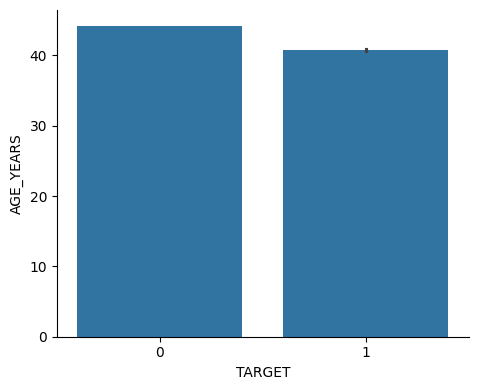

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AGE_YEARS", height=4, aspect=1.2)

In [ ]:
#6 Education vs default rate
''' Defaulters have a lower education than non-defaulters → suggests repayment capacity is a key risk driver.'''

edu_default = (
    app_data.groupby('NAME_EDUCATION_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=False)
)
edu_default

,TARGET
NAME_EDUCATION_TYPE,
Lower secondary,0.109277
Secondary / secondary special,0.089399
Incomplete higher,0.084850
Higher education,0.053551
Academic degree,0.018293


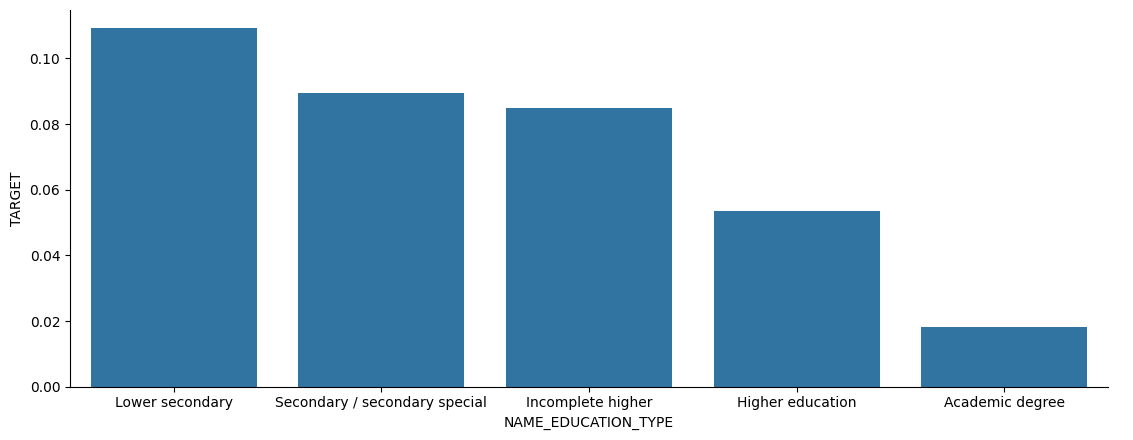

In [ ]:
edu_df = edu_default.reset_index()
sns.catplot(data=edu_df, kind="bar", x="NAME_EDUCATION_TYPE", y="TARGET", height=4.5, aspect=2.5)

In [ ]:
# Slide 7 Gender vs default rate

''' Defaulters are male than non-defaulters → suggests repayment capacity is a key risk driver.'''

' Defaulters are male than non-defaulters → suggests repayment capacity is a key risk driver.'

In [ ]:
gender_default = app_data.groupby('CODE_GENDER')['TARGET'].mean()
gender_default

,TARGET
CODE_GENDER,
F,0.069993
M,0.101419
XNA,0.000000


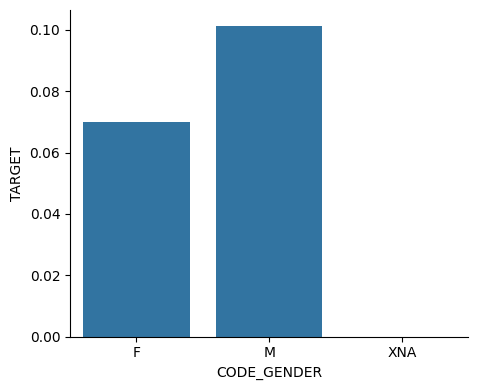

In [ ]:
gender_df = gender_default.reset_index()
sns.catplot(data=gender_df, kind="bar", x="CODE_GENDER", y="TARGET", height=4, aspect=1.2)

In [ ]:
#Slide 8 family status vs default rate

''' Defaulters are married than non-defaulters → suggests repayment capacity is a key risk driver.'''

' Defaulters are married than non-defaulters → suggests repayment capacity is a key risk driver.'

In [ ]:
family_default = (
    app_data.groupby('NAME_FAMILY_STATUS')['TARGET']
    .mean()
    .sort_values(ascending=False)
)
family_default

,TARGET
NAME_FAMILY_STATUS,
Civil marriage,0.099446
Single / not married,0.098077
Separated,0.081942
Married,0.075599
Widow,0.058242
Unknown,0.000000


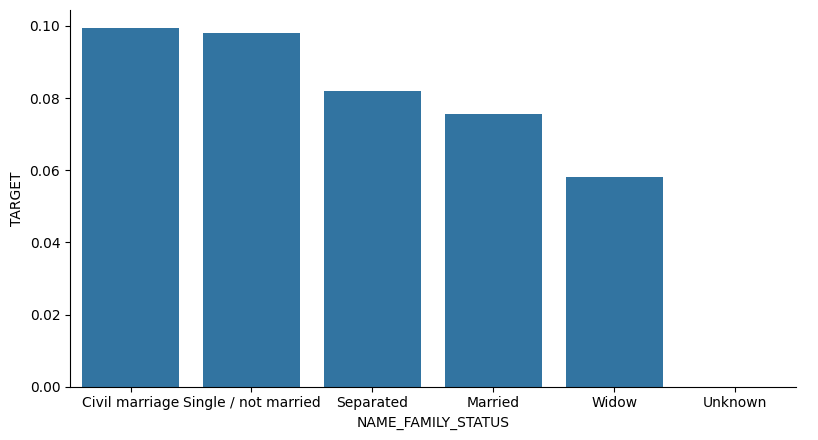

In [ ]:
family_df = family_default.reset_index()
sns.catplot(data=family_df, kind="bar", x="NAME_FAMILY_STATUS", y="TARGET", height=4.5, aspect=1.8)

In [ ]:
# SLide 9 income type vs default

''' Defaulters are working than non-defaulters → suggests repayment capacity is a key risk driver.'''

In [ ]:
income_type_default = (
    app_data.groupby('NAME_INCOME_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=False)
)
income_type_default

,TARGET
NAME_INCOME_TYPE,
Maternity leave,0.400000
Unemployed,0.363636
Working,0.095885
Commercial associate,0.074843
State servant,0.057550
Pensioner,0.053864
Businessman,0.000000
Student,0.000000


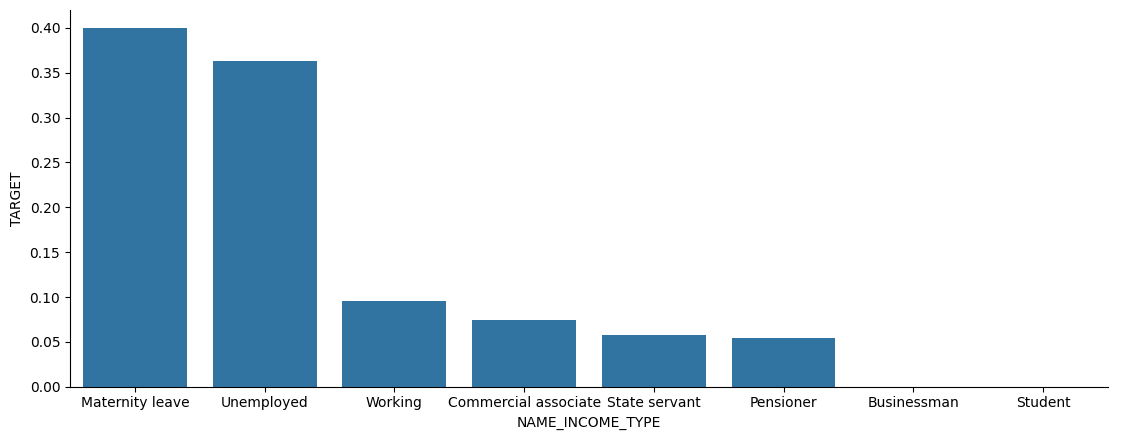

In [ ]:
income_type_df = income_type_default.reset_index()
sns.catplot(data=income_type_df, kind="bar", x="NAME_INCOME_TYPE", y="TARGET", height=4.5, aspect=2.5)

In [ ]:
#slide 10 asset owernship vs default

''' Defaulters are not owning than non-defaulters → suggests repayment capacity is a key risk driver.'''

' Defaulters are not owning than non-defaulters → suggests repayment capacity is a key risk driver.'

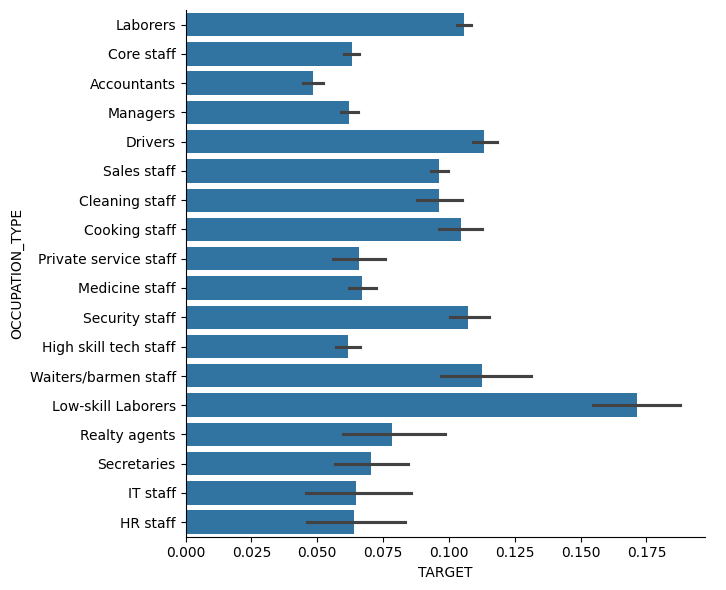

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="OCCUPATION_TYPE", height=6, aspect=1.2)

In [ ]:
realty_default = app_data.groupby('FLAG_OWN_REALTY')['TARGET'].mean()
car_default = app_data.groupby('FLAG_OWN_CAR')['TARGET'].mean()

realty_default, car_default

(FLAG_OWN_REALTY
 N    0.083249
 Y    0.079616
 Name: TARGET, dtype: float64,
 FLAG_OWN_CAR
 N    0.085002
 Y    0.072437
 Name: TARGET, dtype: float64)

In [ ]:
#'''conclusion:
#-overall individuals with lower average incomes and average anuities were more probable to default. By following a system that would allow for a higher annuity amount to be deducted when working would reduce the number of defaulters one retired.
#-Younger individuals have the highest tendency on defaulting, despite being at an age where they are able to work. Conversely, pensioners have the lowest probability of default despite the lack of a steady source of income(apart from retirement savings)
#-As one would anticipate, individuals with a lower education have a higher chance of defaulting. This could be due to poor financial planning, due to the lack of access to resoruces and knowledge about the same. Additionally, having a lower education could result in having blue collared/comparatively lower paying jobs, compared to those with a higher education, making them more prone to defaults.
#-Being married also results in higher defaults, this could be due to having to support more members of the family than an individual that might not be married, reducing available funds due to higher expenditure
#-Despite income inequality, where women are disadvantaged, in several instances, men yet have a higher default rate. This could indicate a better allocation of funds by individuals owing to better financial planning, or in certain cases a difference in the burden of responsibility that could in some cases be higher for men
#-An individual on maternity leave has the highest default rate, followed by an unemployed individual, followed by an individual working, commerical associate, servant and pensioner. While this does not follow a specific pattern determined by specific parameters, an individual on maternity leave could have a sharp increase in medical expenses, spending on supplies for the child etc, alongisde a paycut that could result in a high default rate. Cases of insufficient planning prior to taking a maternity leave can also result in a higher default rate.
#-Non-owners, have a higher default rate. This could potentially be due to the inability of these individuals to liquidate an asset they own, as a way to supplement any possible financial crisis. Additionally, despite the fact that non-ownership could act as an indicator of having lesser responsibilities or lower expenditure, allowing for a lower chance of defaulting, they have a higher chance of defaulting.
#-In general, banks alongside carrying out preliminary annuity, income and education level checks should also consider the level of responsibilities individuals have defined by various metrics. Additionally, banks could focus on targetting women, an older audience, pensioners and those with other assets when considering potential candidates to maximise on their revenue and minimise loan defaults. Additionally, they could provide more flexible loans in certain scenarios such as for those on maternity leaves, to expand their client base and safegaurd themsleves, minimising their losses.


In [ ]:
''' below is messy stuff'''

In [ ]:
app_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.180822
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,52.068493
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,54.608219


In [ ]:
app_data.groupby('CODE_GENDER')['TARGET'].mean()

,TARGET
CODE_GENDER,
F,0.069993
M,0.101419
XNA,0.000000


In [ ]:
app_data.groupby(['NAME_CONTRACT_TYPE','CODE_GENDER','AMT_INCOME_TOTAL'])['TARGET'].describe()

count      mean       std  \
NAME_CONTRACT_TYPE CODE_GENDER AMT_INCOME_TOTAL                              
Cash loans         F           25650.0             2.0  0.500000  0.707107   
                               26100.0             3.0  0.000000  0.000000   
                               26460.0             1.0  0.000000       NaN   
                               26550.0             2.0  0.000000  0.000000   
                               27000.0            53.0  0.056604  0.233295   
...                                                ...       ...       ...   
Revolving loans    M           4500000.0           1.0  0.000000       NaN   
                   XNA         135000.0            1.0  0.000000       NaN   
                               157500.0            1.0  0.000000       NaN   
                               207000.0            1.0  0.000000       NaN   
                               247500.0            1.0  0.000000       NaN   

                                                 min   25%  50%   75%  max  
NAME_CONTRACT_TYPE CODE_GENDER AMT_INCOME_TOTAL                             
Cash loans         F           25650.0           0.0  0.25  0.5  0.75  1.0  
                               26100.0           0.0  0.00  0.0  0.00  0.0  
                               26460.0           0.0  0.00  0.0  0.00  0.0  
                               26550.0           0.0  0.00  0.0  0.00  0.0  
                               27000.0           0.0  0.00  0.0  0.00  1.0  
...                                              ...   ...  ...   ...  ...  
Revolving loans    M           4500000.0         0.0  0.00  0.0  0.00  0.0  
                   XNA         135000.0          0.0  0.00  0.0  0.00  0.0  
                               157500.0          0.0  0.00  0.0  0.00  0.0  
                               207000.0          0.0  0.00  0.0  0.00  0.0  
                               247500.0          0.0  0.00  0.0  0.00  0.0  

[3554 rows x 8 columns]

In [ ]:
app_data.groupby(['NAME_CONTRACT_TYPE','CODE_GENDER','AMT_INCOME_TOTAL'])['TARGET'].describe()

count      mean       std  \
NAME_CONTRACT_TYPE CODE_GENDER AMT_INCOME_TOTAL                              
Cash loans         F           25650.0             2.0  0.500000  0.707107   
                               26100.0             3.0  0.000000  0.000000   
                               26460.0             1.0  0.000000       NaN   
                               26550.0             2.0  0.000000  0.000000   
                               27000.0            53.0  0.056604  0.233295   
...                                                ...       ...       ...   
Revolving loans    M           4500000.0           1.0  0.000000       NaN   
                   XNA         135000.0            1.0  0.000000       NaN   
                               157500.0            1.0  0.000000       NaN   
                               207000.0            1.0  0.000000       NaN   
                               247500.0            1.0  0.000000       NaN   

                                                 min   25%  50%   75%  max  
NAME_CONTRACT_TYPE CODE_GENDER AMT_INCOME_TOTAL                             
Cash loans         F           25650.0           0.0  0.25  0.5  0.75  1.0  
                               26100.0           0.0  0.00  0.0  0.00  0.0  
                               26460.0           0.0  0.00  0.0  0.00  0.0  
                               26550.0           0.0  0.00  0.0  0.00  0.0  
                               27000.0           0.0  0.00  0.0  0.00  1.0  
...                                              ...   ...  ...   ...  ...  
Revolving loans    M           4500000.0         0.0  0.00  0.0  0.00  0.0  
                   XNA         135000.0          0.0  0.00  0.0  0.00  0.0  
                               157500.0          0.0  0.00  0.0  0.00  0.0  
                               207000.0          0.0  0.00  0.0  0.00  0.0  
                               247500.0          0.0  0.00  0.0  0.00  0.0  

[3554 rows x 8 columns]

In [ ]:
columns_description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_data,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_data,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_data,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_data,CODE_GENDER,Gender of the client,NaN
4,7,application_data,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [ ]:
prev_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("app_data:", app_data.shape)
print("prev_app:", prev_app.shape)
print("columns_description:", columns_description.shape)

app_data: (307511, 122)
prev_app: (1157334, 37)
columns_description: (160, 5)


In [ ]:
# what percent default on loans
app_data['TARGET'].value_counts()

print(f'The default percent is {24825/(282686+ 24825)*100}%')

The default percent is 8.072881945686495%


In [ ]:
app_data[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']].head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
0,202500.0,406597.5,24700.5
1,270000.0,1293502.5,35698.5
2,67500.0,135000.0,6750.0
3,135000.0,312682.5,29686.5
4,121500.0,513000.0,21865.5


In [ ]:
#income of default vs non default
app_data.groupby('TARGET')['AMT_INCOME_TOTAL'].mean()



,AMT_INCOME_TOTAL
TARGET,
0,169077.722266
1,165611.760906


In [ ]:
#Credit of default vs non default
app_data.groupby('TARGET')['AMT_CREDIT'].mean()

,AMT_CREDIT
TARGET,
0,602648.282002
1,557778.527674


In [ ]:
# education vs default
#gender vs default
# income vs credit

In [ ]:
edu_default = app_data.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False)

print(edu_default)

NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64


In [ ]:
gender_default = app_data.groupby('CODE_GENDER')['TARGET'].mean()

print(gender_default)

CODE_GENDER
F      0.069993
M      0.101419
XNA    0.000000
Name: TARGET, dtype: float64


In [ ]:
prev_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
app_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
columns_description.groupby(['Row', 'Description']).head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_data,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_data,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_data,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_data,CODE_GENDER,Gender of the client,NaN
4,7,application_data,FLAG_OWN_CAR,Flag if the client owns a car,NaN
...,...,...,...,...,...
155,209,previous_application.csv,DAYS_FIRST_DUE,Relative to application date of current applic...,time only relative to the application
156,210,previous_application.csv,DAYS_LAST_DUE_1ST_VERSION,Relative to application date of current applic...,time only relative to the application
157,211,previous_application.csv,DAYS_LAST_DUE,Relative to application date of current applic...,time only relative to the application
158,212,previous_application.csv,DAYS_TERMINATION,Relative to application date of current applic...,time only relative to the application


In [ ]:
app_data.groupby('TARGET')[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']].mean()


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
TARGET,,,
0,169077.722266,602648.282002,27163.623349
1,165611.760906,557778.527674,26481.744290


In [ ]:


'''AGE_YEARS (create from DAYS_BIRTH)

CNT_CHILDREN

NAME_FAMILY_STATUS

NAME_EDUCATION_TYPE

FLAG_OWN_REALTY

FLAG_OWN_CAR

'''

app_data.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()


,TARGET
NAME_EDUCATION_TYPE,
Academic degree,0.018293
Higher education,0.053551
Incomplete higher,0.084850
Lower secondary,0.109277
Secondary / secondary special,0.089399


In [ ]:
app_data['AGE_YEARS'] = -app_data['DAYS_BIRTH'] / 365

In [ ]:
app_data.groupby('TARGET')['AGE_YEARS'].mean()

,AGE_YEARS
TARGET,
0,44.214182
1,40.780351


In [ ]:
app_data.groupby('TARGET')['CNT_CHILDREN'].mean()

,CNT_CHILDREN
TARGET,
0,0.412946
1,0.463807


In [ ]:
family_default = (
    app_data.groupby('NAME_FAMILY_STATUS')['TARGET']
    .mean()
    .sort_values(ascending=False)
)

family_default

,TARGET
NAME_FAMILY_STATUS,
Civil marriage,0.099446
Single / not married,0.098077
Separated,0.081942
Married,0.075599
Widow,0.058242
Unknown,0.000000


In [ ]:
realty_default = (
    app_data.groupby('FLAG_OWN_REALTY')['TARGET']
    .mean()
)

realty_default

,TARGET
FLAG_OWN_REALTY,
N,0.083249
Y,0.079616


In [ ]:
car_default = (
    app_data.groupby('FLAG_OWN_CAR')['TARGET']
    .mean()
)

car_default

,TARGET
FLAG_OWN_CAR,
N,0.085002
Y,0.072437


In [ ]:
import seaborn as sns

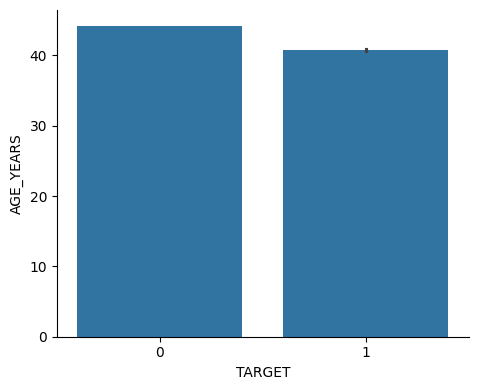

In [ ]:
sns.catplot(data=app_data,
            kind="bar",
            x="TARGET",
            y="AGE_YEARS",
            height=4,
            aspect=1.2)

In [ ]:
#AGE_YEARS (create from DAYS_BIRTH), CNT_CHILDREN, NAME_FAMILY_STATUS

In [ ]:
import seaborn as sns

<Axes: xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

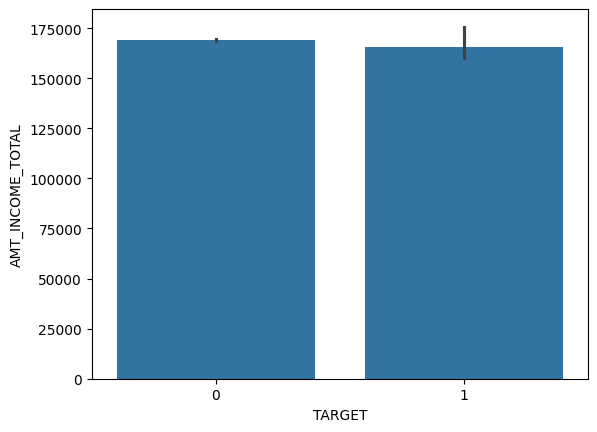

In [ ]:
sns.barplot (data = app_data, x = 'TARGET', y = 'AMT_INCOME_TOTAL')


<Axes: xlabel='TARGET', ylabel='AMT_CREDIT'>

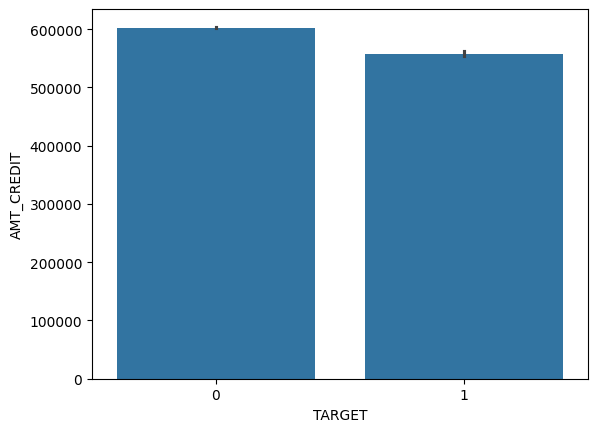

In [ ]:
sns.barplot (data = app_data, x = 'TARGET', y = 'AMT_CREDIT')

<Axes: xlabel='NAME_INCOME_TYPE', ylabel='TARGET'>

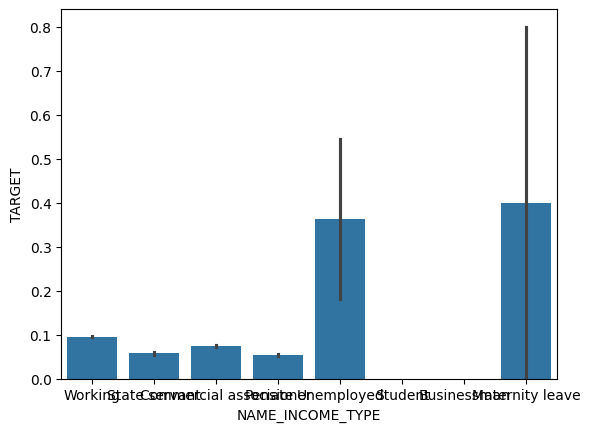

In [ ]:
sns.barplot(data = app_data, x = 'NAME_INCOME_TYPE', y = 'TARGET')

<Axes: xlabel='NAME_FAMILY_STATUS', ylabel='TARGET'>

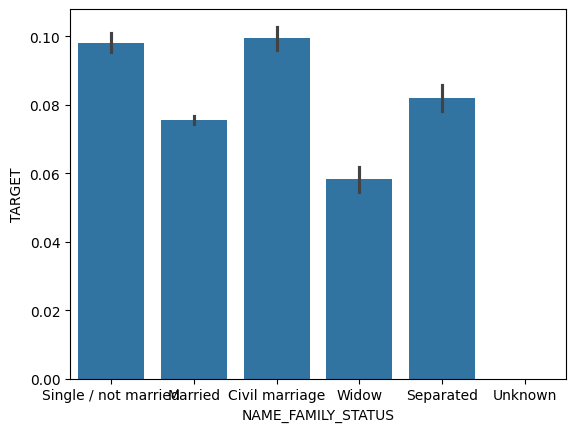

In [ ]:
sns.barplot(data = app_data, x = 'NAME_FAMILY_STATUS', y = 'TARGET')

In [ ]:
#numeric vs target
#reject reason

SyntaxError: invalid syntax (ipython-input-596186582.py, line 3)

In [ ]:
#SLIDE 1(Data set + target overview)
# Basic size
app_data.shape

(307511, 123)

In [ ]:
# Default counts + %
app_data['TARGET'].value_counts()


,proportion
TARGET,
0,0.919271
1,0.080729


In [ ]:
app_data['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


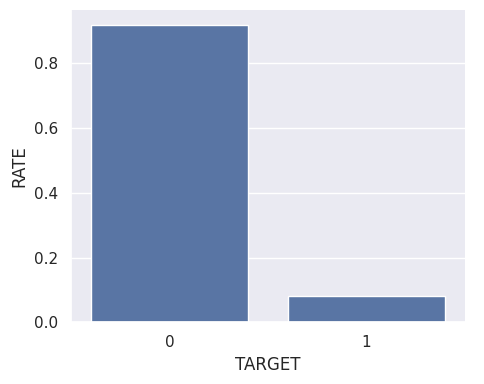

In [ ]:
import seaborn as sns
sns.set_theme()

target_df = app_data['TARGET'].value_counts(normalize=True).reset_index()
target_df.columns = ['TARGET', 'RATE']

sns.catplot(data=target_df, kind="bar", x="TARGET", y="RATE", height=4, aspect=1.2)

In [ ]:
# Slide 2 (Financial Capacity): Income vs Default
app_data.groupby('TARGET')['AMT_INCOME_TOTAL'].mean()


,AMT_INCOME_TOTAL
TARGET,
0,169077.722266
1,165611.760906


In [ ]:
app_data.groupby('TARGET')['AMT_INCOME_TOTAL'].median()

,AMT_INCOME_TOTAL
TARGET,
0,148500.0
1,135000.0


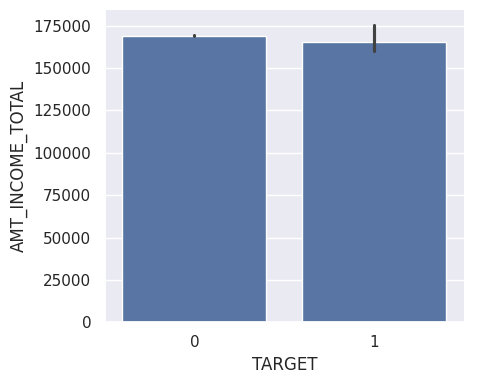

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AMT_INCOME_TOTAL", height=4, aspect=1.2)

In [ ]:
#Slide 3(Credit Amount vs Default)

In [ ]:
app_data.groupby('TARGET')['AMT_CREDIT'].mean()


,AMT_CREDIT
TARGET,
0,602648.282002
1,557778.527674


In [ ]:
app_data.groupby('TARGET')['AMT_CREDIT'].median()

,AMT_CREDIT
TARGET,
0,517788.0
1,497520.0


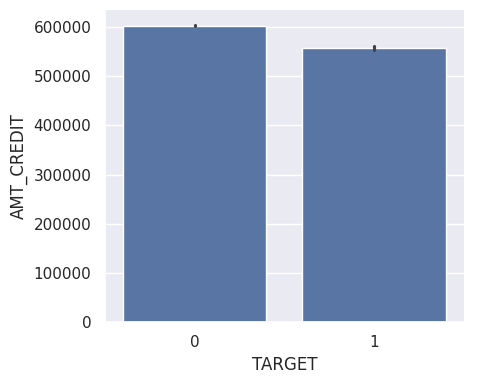

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AMT_CREDIT", height=4, aspect=1.2)

In [ ]:
#Slide 4(Annuity vs Default)

In [ ]:
app_data.groupby('TARGET')['AMT_ANNUITY'].mean()


,AMT_ANNUITY
TARGET,
0,27163.623349
1,26481.744290


In [ ]:
app_data.groupby('TARGET')['AMT_ANNUITY'].median()

,AMT_ANNUITY
TARGET,
0,24876.0
1,25263.0


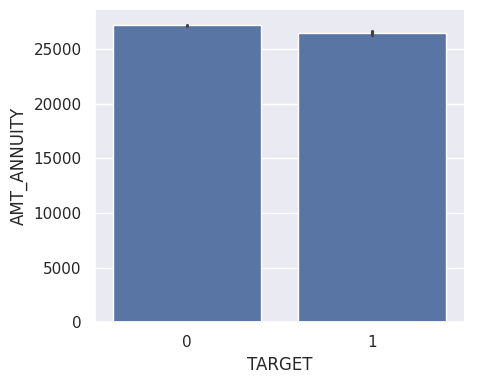

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AMT_ANNUITY", height=4, aspect=1.2)

In [ ]:
# Slide 5 (Age vs Default)
app_data['AGE_YEARS'] = -app_data['DAYS_BIRTH'] / 365

In [ ]:
app_data.groupby('TARGET')['AGE_YEARS'].mean()


,AGE_YEARS
TARGET,
0,44.214182
1,40.780351


In [ ]:
app_data.groupby('TARGET')['AGE_YEARS'].median()

,AGE_YEARS
TARGET,
0,43.498630
1,39.128767


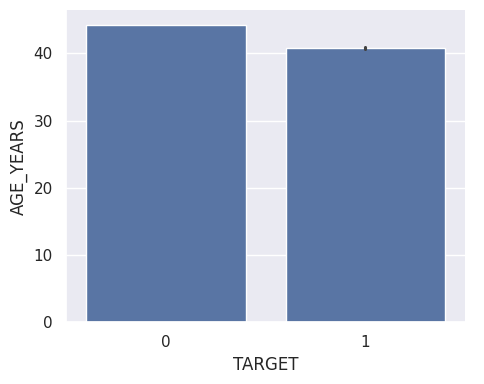

In [ ]:
sns.catplot(data=app_data, kind="bar", x="TARGET", y="AGE_YEARS", height=4, aspect=1.2)

In [ ]:
# Slide 6 (Education vs Default)

In [ ]:
edu_default = (app_data.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False))

print(edu_default)



NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64


In [ ]:
#Slide 7 - Gender vs Default

In [ ]:
app_data.groupby('CODE_GENDER')['TARGET'].mean()

,TARGET
CODE_GENDER,
F,0.069993
M,0.101419
XNA,0.000000


In [ ]:
#slide 8 Ownership Stability: property / car compared to default rate

In [ ]:
app_data.groupby('FLAG_OWN_REALTY')['TARGET'].mean()


,TARGET
FLAG_OWN_REALTY,
N,0.083249
Y,0.079616


In [ ]:
app_data.groupby('FLAG_OWN_CAR')['TARGET'].mean()

,TARGET
FLAG_OWN_CAR,
N,0.085002
Y,0.072437


In [ ]:
'''
Case study question:

“What makes it more likely that a client will default (TARGET=1)?”

Your final answer should be 3 parts:
1) Key risk drivers you observed (top 3–5)

Use the variables where the default rate difference is biggest:

Income type / employment stability (NAME_INCOME_TYPE)

Education level (NAME_EDUCATION_TYPE)

Repayment burden signals (AMT_ANNUITY, AMT_CREDIT)

Age / life-stage (AGE_YEARS)

Asset ownership stability (FLAG_OWN_REALTY / FLAG_OWN_CAR)

Family burden (NAME_FAMILY_STATUS, CNT_CHILDREN)

2) Interpret them in business terms

Examples:

Lower/stabler income → repayment struggles

Higher installment burden → cash flow pressure

Lower education / unstable income types → higher risk segments

Asset ownership → stability buffer

3) Actions the lender could take

Require stronger verification for high-risk segments

Reduce loan size for risky profiles

Price risk higher (higher rates) for high-risk groups

Prefer more stable income sources / education levels in scoring

What I still need from you (to write the exact final conclusion)

Right now you gave code, but not the numerical outputs.

Copy-paste these outputs (just the tables):

app_data['TARGET'].value_counts(normalize=True)

app_data.groupby('TARGET')[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']].mean()

edu_default

income_type_default

family_default

realty_default and car_default

app_data.groupby('TARGET')['AGE_YEARS'].mean()

Once you paste those, I’ll write:

Your final “findings” paragraph

A bullet list for your last slide

A 30–60 second talk track that sounds like a real risk analyst.'''